# H-He Mixture

In this notebook we will calculate the diffusion and interdiffusion coefficients of Binary Ionic Mixture (BIM) of Hydrogen and Helium. This notebook tries to reproduce the data obtained from Hansen, Joly, and McDonald's [paper](https://doi.org/10.1016/0378-4371(85)90022-6).

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/BIM/input_files/BIM_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/BIM/H-He_Mixture.ipynb).

In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
plt.style.use('MSUstyle')
# Import sarkas
from sarkas.processes import PostProcess


# Create the file path to the YAML input file
input_file_name = os.path.join('input_files', 'HHe_cgs.yaml')

In [2]:
# from sarkas.processes import PreProcess
# pre = PreProcess(input_file_name)
# pre.setup(read_yaml=True)

# # pre.run(pppm_estimate=False)

## Simulation

In [3]:
# sim = Simulation(input_file_name)
# sim.setup(read_yaml=True)
# sim.run()

## PostProcessing


In [4]:
postproc = PostProcess(input_file_name, grab_last_step=True)
postproc.setup(read_yaml=True)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


### Thermodynamic Check

Let's make sure that the equilibration phase was $NVT$ and the production phase $NVE$.

In [5]:
from sarkas.tools.observables import Thermodynamics
import xarray as xr

no_slices = 1
therm = Thermodynamics()
therm.setup(postproc.parameters, 
            phase = "production",
            no_slices=no_slices)
therm.compute()

# ds = xr.open_zarr(therm.zarr_store_path)
# print(ds)



=========================== Thermodynamics ===========================
Data saved in: 
 Simulations/HHe_sim/PostProcessing/Thermodynamics/Production/HHe_sim.h5

Time Series Data:
No. of blocks = 1
No. dumps per block = 1000
Total time per block: T = 3.0823e-14 [s] ~ 822 plasma periods
Time interval: dt = 3.0823e-17 [s] ~ 8.2e-01 plasma period


In [6]:
ds = therm._read_dataset()

ds.info

<bound method Dataset.info of <xarray.Dataset> Size: 440kB
Dimensions:     (species: 3, quantity: 6, time: 1000, slice: 1)
Coordinates:
  * species     (species) <U5 60B 'H' 'He' 'Total'
  * quantity    (quantity) <U16 384B 'Total Energy' 'Temperature' ... 'Enthalpy'
  * time        (time) float64 8kB 0.0 3.082e-17 ... 3.076e-14 3.079e-14
  * slice       (slice) int64 8B 0
Data variables:
    mean_therm  (species, quantity, time) float64 144kB -3.946e-06 ... 1.952e-06
    std_therm   (species, quantity, time) float64 144kB 0.0 0.0 0.0 ... 0.0 0.0
    therm       (species, quantity, time, slice) float64 144kB -3.946e-06 ......>

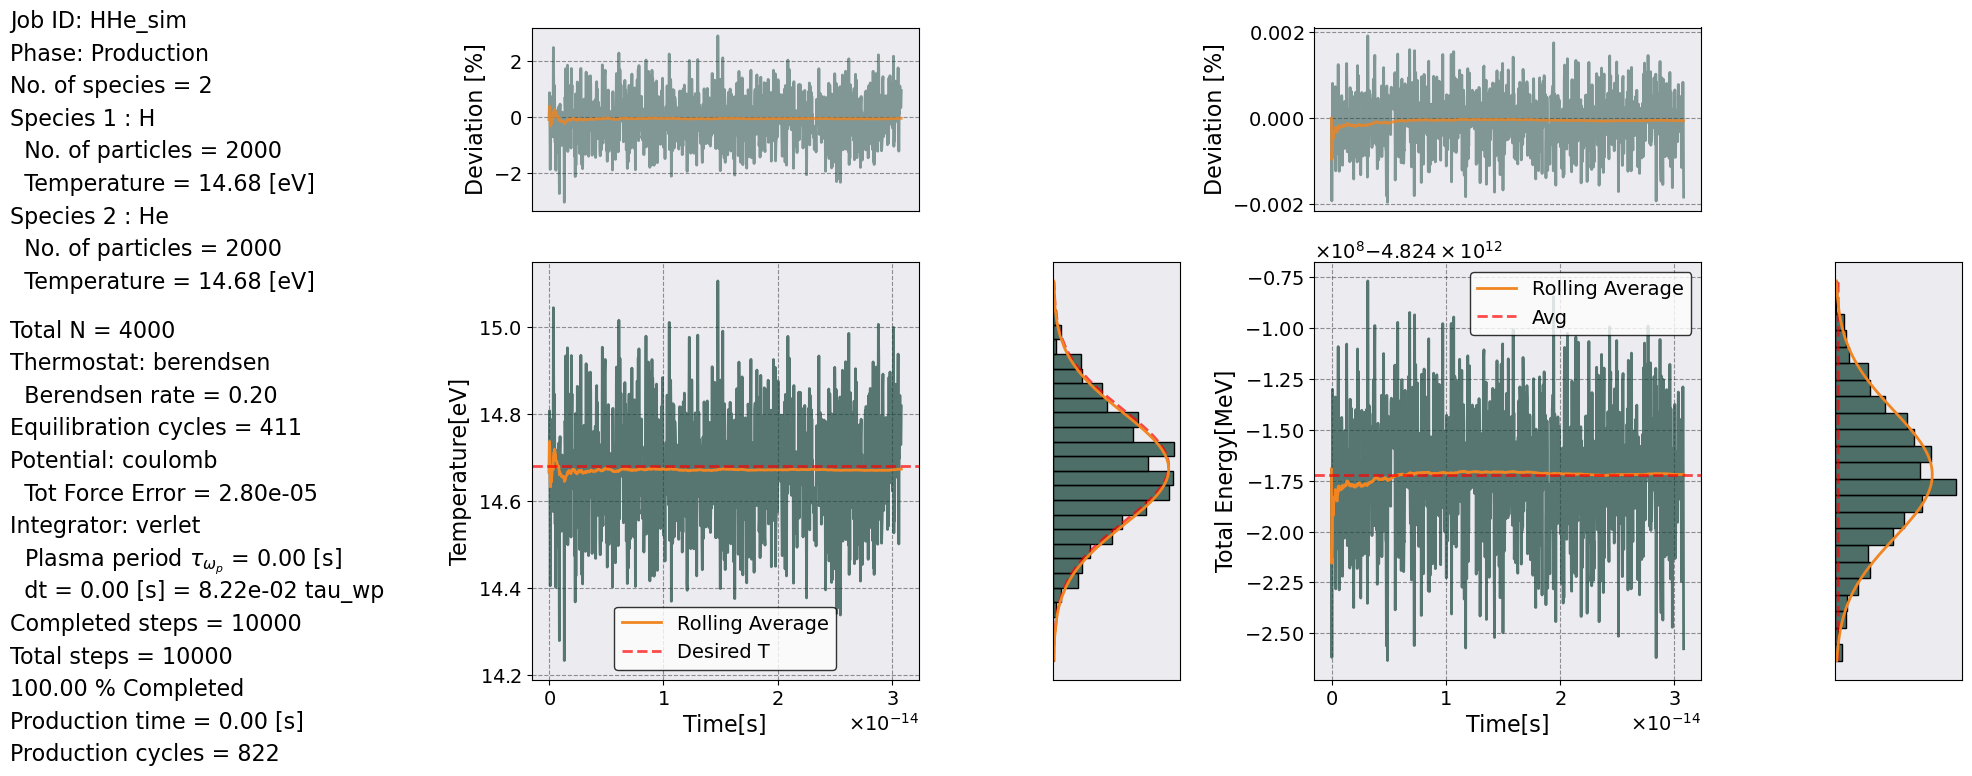

In [7]:
fig, T_axes, E_axes = therm.temp_energy_plot(
    postproc,          # pass the Process object for the info panel
    phase='production',
)

### Pair Distribution Function

Let's look at $g_{\alpha \beta}(r)$. Just for fun.

In [8]:
from sarkas.tools.observables import RadialDistributionFunction
import xarray as xr

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters, no_slices=no_slices)
cutoff_radius = rdf.box_lengths[0] / 2
# rdf_nbins = 500
# rdf.recalculate(**{"cutoff_radius": cutoff_radius, "rdf_nbins": rdf_nbins})
rdf.compute()
rdf_ds = rdf._read_dataset()
print(rdf_ds)



==================== Radial Distribution Function ====================
Data saved in: 
 Simulations/HHe_sim/PostProcessing/RadialDistributionFunction/Production/HHe_sim.h5

Time Series Data:
No. of blocks = 1
No. dumps per block = 1000
Total time per block: T = 3.0823e-14 [s] ~ 822 plasma periods
Time interval: dt = 3.0823e-17 [s] ~ 8.2e-01 plasma period
<xarray.Dataset> Size: 20kB
Dimensions:       (species_pair: 3, r: 250, slice: 1)
Coordinates:
  * species_pair  (species_pair) <U5 60B 'H-H' 'H-He' 'He-He'
  * r             (r) float64 2kB 3.432e-12 1.03e-11 ... 1.706e-09 1.713e-09
  * slice         (slice) int64 8B 0
Data variables:
    mean_rdf      (species_pair, r) float64 6kB 0.0 0.0 0.0 ... 1.004 1.003
    rdf           (species_pair, r, slice) float64 6kB 0.0 0.0 ... 1.004 1.003
    std_rdf       (species_pair, r) float64 6kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0


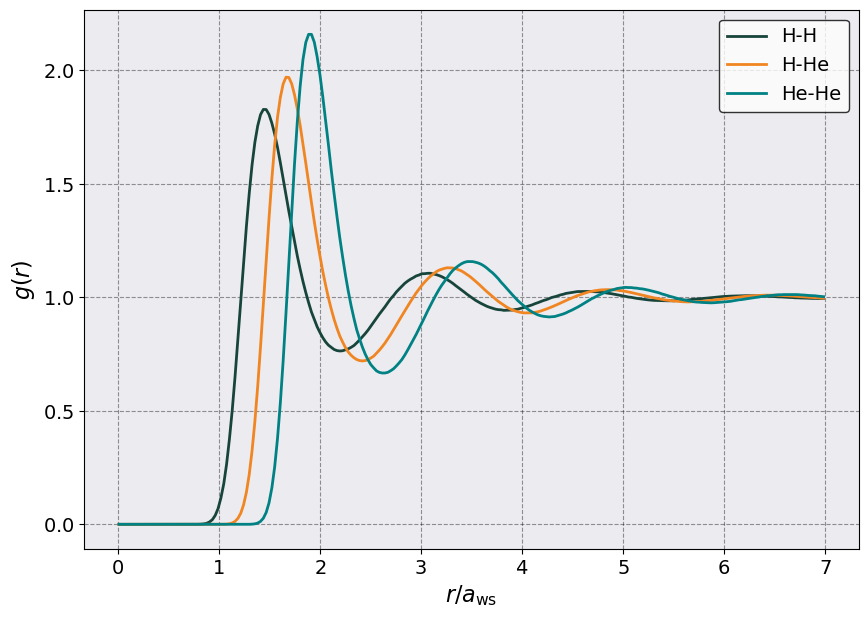

In [9]:
# Plot the RDF with error bars
fig, ax = plt.subplots()

for k, species_pair in enumerate(rdf_ds.species_pair.values):
    r = rdf_ds.r.values/rdf.a_ws
    g_r = rdf_ds["mean_rdf"].sel(species_pair=species_pair)

    ax.plot(r, g_r, label=f'{species_pair}')
    
ax.set(xlabel=r'$r/a_{\rm ws}$', ylabel=r'$g(r)$', title="", )
ax.legend()
figpath = os.path.join(rdf.saving_dir, "rdf_plot.png")
fig.savefig(figpath, dpi=300)

### Static Structure Function

Let's calculate $S_{\alpha\beta}(k)$ up to $ka = 5$ and angle average it.

In [10]:
from sarkas.tools.observables import StaticStructureFactor

ssf = StaticStructureFactor()
ssf.no_slices = 4
ssf.angle_averaging = 'full'
ssf.max_ka_value = 5
ssf.setup(postproc.parameters)
ssf.compute()




====================== Static Structure Factor =======================
Data saved in: 
 Simulations/HHe_sim/PostProcessing/StaticStructureFactor/Production/HHe_sim.h5

Time Series Data:
No. of blocks = 4
No. dumps per block = 250
Total time per block: T = 7.7058e-15 [s] ~ 206 plasma periods
Time interval: dt = 3.0823e-17 [s] ~ 8.2e-01 plasma period
K-space cache: Simulations/HHe_sim/PostProcessing/k_space_data/kspace_cache_HHe_sim.h5

Wave vector parameters:
  angle_averaging : full
  max_k_harmonics : [11 11 11]



In [11]:
ssf_ds = ssf._read_dataset()
print(ssf_ds)

<xarray.Dataset> Size: 39kB
Dimensions:       (species_pair: 3, ka: 254, slice: 4)
Coordinates:
  * species_pair  (species_pair) <U5 60B 'H-H' 'H-He' 'He-He'
  * ka            (ka) float64 2kB 0.2455 0.3473 0.4253 ... 4.413 4.541 4.678
  * slice         (slice) int64 32B 0 1 2 3
Data variables:
    Sk            (species_pair, ka, slice) float64 24kB 1.095 0.5049 ... 0.8638
    mean_Sk       (species_pair, ka) float64 6kB 0.7923 0.9517 ... 1.103 0.989
    std_Sk        (species_pair, ka) float64 6kB 0.2795 0.1078 ... 0.08698


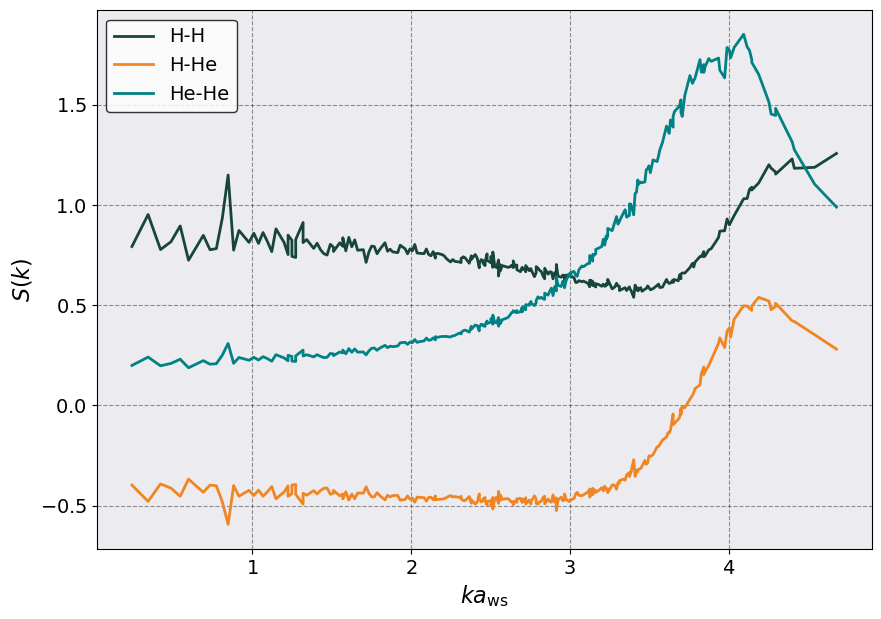

In [12]:
fig, ax = plt.subplots()
for k, species_pair in enumerate(ssf_ds.species_pair.values):
    ka = ssf_ds.ka.values
    Sk = ssf_ds["mean_Sk"].sel(species_pair=species_pair)

    ax.plot(ka, Sk, label=f'{species_pair}')
ax.set(xlabel=r'$ka_{\rm ws}$', ylabel=r'$S(k)$', title="", )
ax.legend()

## Interdiffusion

The interdiffusion coefficient is calculated by the Green-Kubo relation 

$$ D_{12} = \frac{\mathcal{J}}{3Nx_1x_2} \int_0^\infty dt {\rm{{ACF}_{ID}}} = \frac{\mathcal{J}}{3Nx_1x_2} \int_0^\infty dt \langle \mathbf{j}(0) \cdot \mathbf{j}(t) \rangle, $$

where $\mathcal{J}$ is the thermodynamic factor

$$ \mathcal{J} = \frac{x_1x_2}{S_{cc}(k = 0)} $$

and $S_{cc}(k)$ is the concentration-concentration structure factor that can be decomposed into partial structure factors as

$$ S_{cc}(k) = x_1x_2[x_2S_{11}(k) + x_1S_{22}(k) - 2\sqrt{x_1x_2}S_{12}(k)]. $$

Calculating the interdiffusion coefficient $D_{12}$ is two-fold in that we must compute the auto-correlation function $\rm{{ACF}_{ID}}$ and the thermodynamic factor $\mathcal J$.

We will calculate $\mathcal J$ first by fitting the following function to $S_{\alpha\beta}(k)$

In [13]:
# Define fitting functions
from scipy.optimize import curve_fit

def poly_fit(x, a, b, c):
    return a*x**2 + b*x + c

def lin_fit(x, a, b):
    return a*x + b

def inv_fit(x, a, b, c):
    return a*np.exp(b*x) + c

As you can see from above $S_{\alpha\beta}(k)$ are pretty noisy. Therefore we choose only those $ka$ values for which we have averaged more than three $S_{\alpha\beta}(k)$.

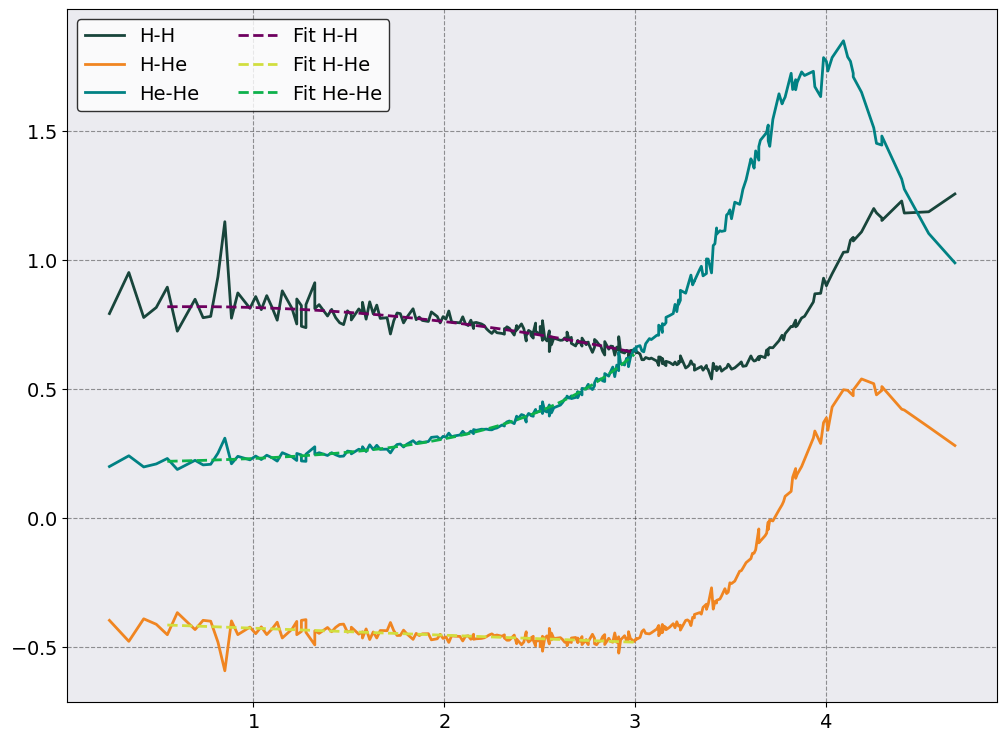

In [14]:
# Create masks
mask = ssf.k_counts > 3
ka_values_full = ssf.ka_values[mask]

ka_mask = ka_values_full < 3.0
ka_values = ka_values_full[ka_mask]

# Remake the plot        
fig, ax = plt.subplots(1,1, figsize = (12,9))

for k, species_pair in enumerate(ssf_ds.species_pair.values):
    ka = ssf_ds.ka.values
    Sk = ssf_ds["mean_Sk"].sel(species_pair=species_pair)

    ax.plot(ka, Sk, label=f'{species_pair}')

# H-H Fit and plot
# Mask the data for fitting
sk_masked = ssf_ds["mean_Sk"].sel(species_pair="H-H").values[mask]
poptH, pcov = curve_fit(poly_fit, ka_values, sk_masked[ka_mask])
ax.plot(ka_values, poly_fit(ka_values, *poptH), ls='--', label = f'Fit H-H')

# H-He Fit and plot
sk_masked = ssf_ds["mean_Sk"].sel(species_pair="H-He").values[mask]
poptHHe, pcov = curve_fit(lin_fit, ka_values, sk_masked[ka_mask])
ax.plot(ka_values, lin_fit(ka_values, *poptHHe),  ls='--', label = f'Fit H-He')

# He-He Fit and plot
sk_masked = ssf_ds["mean_Sk"].sel(species_pair="He-He").values[mask]
poptHe, pcov = curve_fit(inv_fit, ka_values, sk_masked[ka_mask])
ax.plot(ka_values, inv_fit(ka_values, *poptHe),  ls='--', label = f'Fit He-He')

ax.legend(ncol =2 )

Pretty good, right? Now for the thermodynamic factor

In [15]:
x1, x2 = ssf.species_concentrations
Scc_k0 = x1*x2*(x2*inv_fit(0, *poptHe) + x1*poly_fit(0, *poptH) - 2*np.sqrt(x1*x2)*lin_fit(0, *poptHHe))
Therm_factor = x1*x2/Scc_k0
print('J = {:.4f}'.format(Therm_factor) )

J = 1.1001


The value is ~ 1 which is what Hansen *et al.* assumed. Therefore we won't use it below.

In [22]:
from sarkas.tools.observables import DynamicStructureFactor


dsf = DynamicStructureFactor()
dsf.no_slices = 4
dsf.angle_averaging = 'full'
dsf.max_ka_value = 5
dsf.setup(postproc.parameters)
dsf.compute()



====================== Dynamic Structure Factor ======================
Data saved in: 
 Simulations/HHe_sim/PostProcessing/DynamicStructureFactor/Production/HHe_sim.h5

Time Series Data:
No. of blocks = 4
No. dumps per block = 250
Total time per block: T = 7.7058e-15 [s] ~ 206 plasma periods
Time interval: dt = 3.0823e-17 [s] ~ 8.2e-01 plasma period
K-space cache: Simulations/HHe_sim/PostProcessing/k_space_data/kspace_cache_HHe_sim.h5

Wave vector parameters:
  angle_averaging : full
  max_k_harmonics : [11 11 11]



DSF slices: 100%|██████████| 4/4 [00:00<00:00,  4.52it/s]


Dynamic Structure Factor Calculation Time: 0 sec 988 msec 942 usec 625 nsec


In [ ]:
dsf_ds = dsf._read_dataset()
print(dsf_ds)

<xarray.Dataset> Size: 9MB
Dimensions:       (species_pair: 3, ka: 254, frequency: 250, slice: 4)
Coordinates:
  * species_pair  (species_pair) <U5 60B 'H-H' 'H-He' 'He-He'
  * ka            (ka) float64 2kB 0.2455 0.3473 0.4253 ... 4.413 4.541 4.678
  * frequency     (frequency) float64 2kB -1.019e+17 -1.011e+17 ... 1.011e+17
  * slice         (slice) int64 32B 0 1 2 3
Data variables:
    Skw           (species_pair, ka, frequency, slice) float64 6MB 5.097e-22 ...
    mean_Skw      (species_pair, ka, frequency) float64 2MB 4.015e-22 ... 6.0...
    std_Skw       (species_pair, ka, frequency) float64 2MB 2.623e-22 ... 4.2...


[Text(0, 0.5, '$\\omega_p |S_{\\alpha,\\beta}(k,\\omega)|$')]

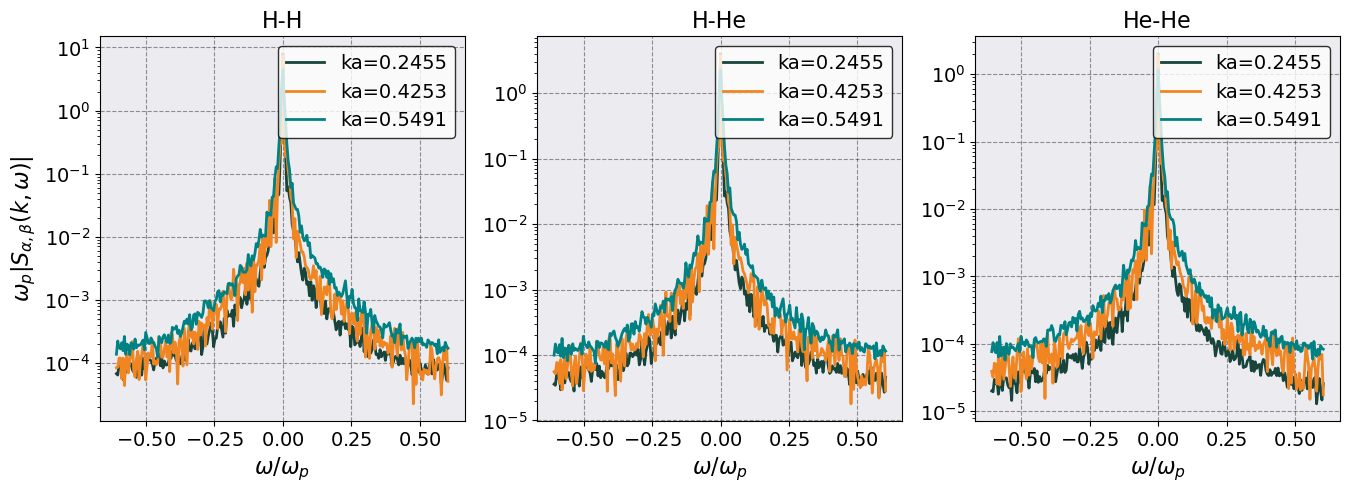

In [85]:
fig, ax = plt.subplots(1,3, figsize = (16, 5), sharex=True)
for sp, species_pair in enumerate(dsf_ds.species_pair.values):
    for k, ka in enumerate(dsf_ds.ka.values[:5][::2]):
        S_k_omega = dsf_ds["mean_Skw"].sel(species_pair=species_pair, ka=ka).values
        w = dsf_ds.frequency.values / dsf.total_plasma_frequency
        ax[sp].plot(w, np.abs(S_k_omega)*dsf.total_plasma_frequency, label=f'ka={ka:.4f}')
    ax[sp].set_title(f'{species_pair}')

for a in ax:
    a.set(yscale='log',
        xlabel=r'$\omega/\omega_p$',
    )
    a.legend()
ax[0].set(ylabel=r'$\omega_p |S_{\alpha,\beta}(k,\omega)|$')

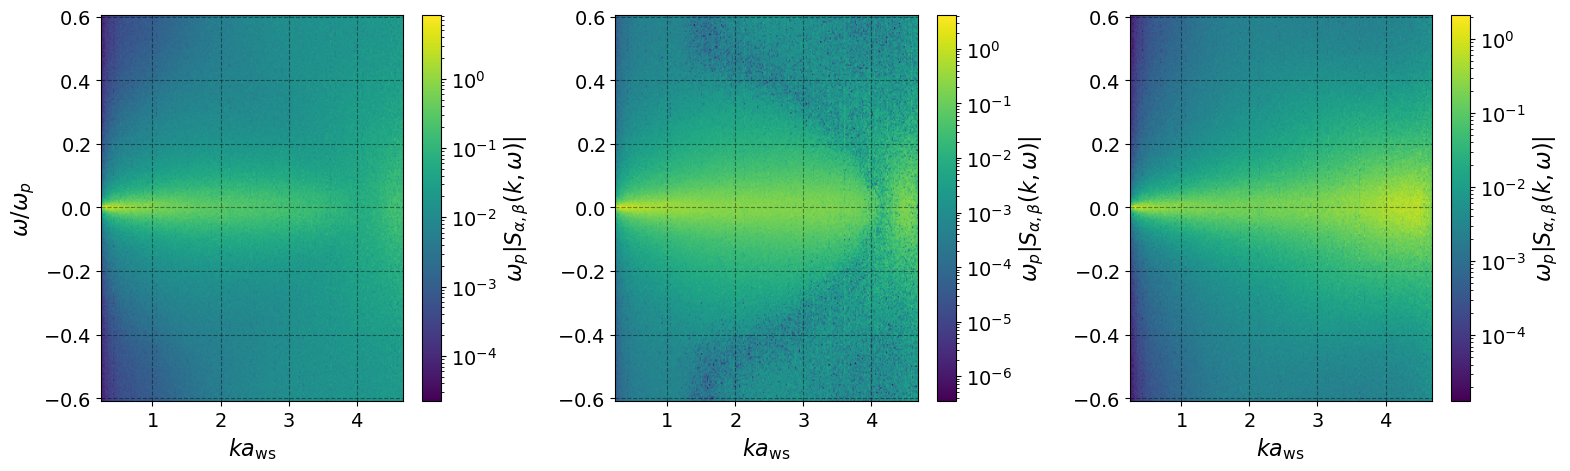

In [86]:
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(1,3, figsize = (16, 5), sharex=True)
for sp, species_pair in enumerate(dsf_ds.species_pair.values):
    S_k_omega = dsf_ds["mean_Skw"].sel(species_pair=species_pair).values * dsf.total_plasma_frequency
    w = dsf_ds.frequency.values / dsf.total_plasma_frequency
    p = ax[sp].imshow(np.abs(S_k_omega).T, 
        extent=[dsf.ka_values.min(), dsf.ka_values.max(), w.min(), w.max()], 
        aspect='auto', origin='lower',
        norm=LogNorm(vmin=np.abs(S_k_omega).min(), vmax=np.abs(S_k_omega).max()),)
    
    fig.colorbar(p, ax=ax[sp], label=r'$\omega_p | S_{\alpha,\beta}(k,\omega)|$')
for a in ax:
    a.set(
        # yscale='log',
        # ylabel=r'$\omega/\omega_p$',
        xlabel=r'$ka_{\rm ws}$',
    )
    # a.legend()
ax[0].set(ylabel=r'$\omega/\omega_p$')
fig.tight_layout()

### Transport Coefficients in Sarkas
Calculating transport coefficients is easy once the [TransportCoefficients](../../api/tools_subpckg/sarkas.tools.transport.TransportCoefficients.rst#sarkas.tools.transport.TransportCoefficients) class from the [sarkas.tools.transport](../../api/tools_subpckg/sarkas.tools.transport.rst) subpackage is imported. 

[Interdiffusion](../../api/tools_subpckg/TransportCoefficients_methods/sarkas.tools.transport.TransportCoefficients.interdiffusion.rst#sarkas.tools.transport.TransportCoefficients.interdiffusion) is a method of [TransportCoefficients](../../api/tools_subpckg/sarkas.tools.transport.TransportCoefficients.rst#sarkas.tools.transport.TransportCoefficients) as such we need to initialize the class first which requires the following inputs

        Parameters
        ----------
        params : sarkas.base.Parameters
            Simulation's parameters.
        
        phase : str, optional
            Phase to compute. Default = 'production'.
        
        no_slices : int, optional
            Number of slices of the simulation. Default = 1.
                
        **kwargs:
            Arguments to pass :meth:`sarkas.tools.observables.FluxAutoCorrelationFunction`

The parameter ``params`` is required as it contains relevant information. Notice the parameter ``no_slices``. This represents the number of divisions in which we want to divide the full length of the time series. For each of these ``slices`` the method will integrate the ACF of the observable to get the transport coefficient.

The calculation of the transport coefficient is achieved by calling the method and passing the appropriate observable objects. The docstring can be found [here](../../api/tools_subpckg/TransportCoefficients_methods/sarkas.tools.transport.TransportCoefficients.interdiffusion.rst#sarkas.tools.transport.TransportCoefficients.interdiffusion). As you can see it requires the appropriate observable which in this case is [interdiffusion_df_slices](../../api/tools_subpckg/sarkas.tools.observables.DiffusionFlux.rst).
The transport coefficient of each slice will be stored as a column of a `pandas.DataFrame` called [interdiffusion_df_slices](../../api/tools_subpckg/TransportCoefficients_methods/sarkas.tools.transport.TransportCoefficients.interdiffusion.rst), the Mean and Std (over slices) will be stored in the [interdiffusion_df](../../api/tools_subpckg/TransportCoefficients_methods/sarkas.tools.transport.TransportCoefficients.interdiffusion.rst).  

The first column of these dataframes corresponds to the time in sec of each timestep.

The option ``plot=True`` will make a figure with two plots. On the left the ACF as a function of time and on the right a plot of the transport coefficient as a function of time with the corresponding errorband.

In [17]:
from sarkas.tools.transport import TransportCoefficients
from sarkas.tools.observables import DiffusionFlux


ImportError: cannot import name 'plot_labels' from 'sarkas.tools.observables' (/Users/silves28/Documents/Codes/sarkas/sarkas/tools/observables/__init__.py)

In [ ]:
# Compute the diffusion flux by dividing the simulations into 4 smaller simulations
jc_acf = DiffusionFlux()
jc_acf.no_slices = 4
jc_acf.setup(postproc.parameters)
jc_acf.compute(from_pva=True)

In [ ]:
# Let's look at it 
ds = xr.open_zarr(jc_acf.zarr_store_path)
print(ds)

Notice that there is a column `Diffusion Flux 0` and `Diffusion Flux ACF 0` for each slice. For the transport coefficient I will use `Diffusion Flux ACF 0`.

In [ ]:
tc = TransportCoefficients(
        postproc.parameters,
        no_slices = 4)
tc.interdiffusion(jc_acf, plot = True)
# Note the info printed to screen

In [ ]:
# Let's look at what we have
tc.interdiffusion_df

As mentioned the InterDiffusion is calculated for each slice and then averaged. The left plot above shows the mean over the four slices of the Diffusion Flux ACF with its standard deviation as the shaded area. The upper x-axis (Index) indicates the index value in the dataframe.

Let's now plot this and compare with Hansen *et al.* result.

In [ ]:
aws = postproc.parameters.a_ws
vaa = postproc.parameters.hydrodynamic_frequency
norm = 1/(vaa * aws**2 )

fig, ax = plt.subplots(1,1)
ax.plot(
    tc.interdiffusion_df["Time"]*1e15,
    tc.interdiffusion_df[("Inter Diffusion Flux 0","Mean")] * norm , 
    label = 'Sarkas')
ax.plot(
    tc.interdiffusion_df["Time"]*1e15, 
    norm * tc.interdiffusion_df[("Inter Diffusion Flux 0","Mean")].expanding().mean())

ax.fill_between( 
    tc.interdiffusion_df["Time"].iloc[:,0]*1e15, # I don't understand why I need iloc here but not above
    (tc.interdiffusion_df[("Inter Diffusion Flux 0","Mean")] - tc.interdiffusion_df[("Inter Diffusion Flux 0","Std")])*norm,
    (tc.interdiffusion_df[("Inter Diffusion Flux 0","Mean")] + tc.interdiffusion_df[("Inter Diffusion Flux 0","Std")])*norm,
    alpha = 0.4)

ax.axhline(0.0109, color = 'r', ls = '--', label='HJM value')
ax.legend()
ax.set(xscale = 'log', xlabel = 'Time [fs]', title = r'H-He Interdiffusion $\Gamma = 40$')


Looks good to me! 